Root cause analysis for changes in ΔT2 and ΔTc

In [1]:
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import xwrf

In [2]:
run_dir = '/project2/zhan248_1326/hhao4018/WRFv4.6.1_Modified_AHoption_noChem/test'
simulations = {
    "target": {
        "summer": "JOE_Default_08_ah=2_GDAS_frac_urb_v2",
        "winter": "JOE_Default_12_ah=2_GDAS_frac_urb_v2",
    },
    "control": {
        "summer": "JOE_Default_2016_08_ah=0_v2",
        "winter": "JOE_Default_2016_12_ah=0_v2",
    }
}

In [3]:
# test on one experiment 
exp = "JOE_Default_08_ah=2_GDAS_frac_urb_v2"
out_dir = os.path.join(run_dir, exp)
# pattern for all wrfout_d02 files
filelist = sorted(glob.glob(os.path.join(out_dir, "wrfout_d02*")))

ds = xr.open_mfdataset(filelist, 
                    engine="netcdf4",
                    concat_dim="Time",
                    combine="nested").xwrf.postprocess()
ds

<xarray.Dataset> Size: 16GB
Dimensions:                    (Time: 217, y: 192, x: 244, z: 44,
                                urban_wind_directions_stag: 4, z_stag: 45)
Coordinates:
  * Time                       (Time) datetime64[us] 2kB 2016-08-10 ... 2016-...
    XTIME                      (Time) datetime64[ns] 2kB dask.array<chunksize=(1,), meta=np.ndarray>
  * y                          (y) float64 2kB -4.254e+05 ... -2.344e+05
  * x                          (x) float64 2kB 1.325e+05 1.335e+05 ... 3.755e+05
    XLAT                       (y, x) float32 187kB dask.array<chunksize=(192, 244), meta=np.ndarray>
    XLONG                      (y, x) float32 187kB dask.array<chunksize=(192, 244), meta=np.ndarray>
Dimensions without coordinates: z, urban_wind_directions_stag, z_stag
Data variables: (12/99)
    Times                      (Time) |S19 4kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX                   (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    Q2                         (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    T2                         (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    PSFC                       (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    U10                        (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    ...                         ...
    LANDMASK                   (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    LAKEMASK                   (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    SST                        (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    SST_INPUT                  (Time, y, x) float32 41MB dask.array<chunksize=(1, 192, 244), meta=np.ndarray>
    air_potential_temperature  (Time, z, y, x) float32 2GB dask.array<chunksize=(1, 44, 192, 244), meta=np.ndarray>
    wrf_projection             object 8B +proj=lcc +x_0=0 +y_0=0 +a=6370000 +...
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2016-08-10_00:00:00
    SIMULATION_START_DATE:           2016-08-10_00:00:00
    WEST-EAST_GRID_DIMENSION:        245
    SOUTH-NORTH_GRID_DIMENSION:      193
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      0
    ETAC:                            0.0

In [4]:
# print all variables to txt file 
out_dir = "../data"
output_file = os.path.join(out_dir, "wrf_variables.txt")

with open(output_file, "w") as f:
    f.write("=== DATA VARIABLES ===\n\n")
    for var in ds.data_vars:
        f.write(f"{var}\n")
        for attr, val in ds[var].attrs.items():
            f.write(f"  {attr}: {val}\n")
        f.write("\n")

    f.write("\n=== COORDINATES ===\n\n")
    for coord in ds.coords:
        f.write(f"{coord}\n")
        for attr, val in ds[coord].attrs.items():
            f.write(f"  {attr}: {val}\n")
        f.write("\n")

print(f"Saved to: {output_file}")

Saved to: ../data/wrf_variables.txt


In [5]:
def compute_diurnal_cycle(exp_name, varname, urban_mask_xr, reduce_method="surface"):
    """
    Generic diurnal cycle computation for WRF variables or derived variables.

    varname can be:
        - string: "LH", "PBLH", etc.
        - special: "delta_T_canopy", "delta_T_surface"
    """

    out_dir = os.path.join(run_dir, exp_name)
    filelist = sorted(glob.glob(os.path.join(out_dir, "wrfout_d02*")))

    ds = xr.open_mfdataset(
        filelist,
        engine="netcdf4",
        concat_dim="Time",
        combine="nested"
    ).xwrf.postprocess()

    # ---- Convert UTC → Pacific ----
    time_local = pd.to_datetime(ds["Time"].values)\
        .tz_localize("UTC")\
        .tz_convert("America/Los_Angeles")\
        .tz_localize(None)

    ds = ds.assign_coords(Time=time_local)

    # ---- Handle derived variables ----
    if varname == "delta_T_canopy":
        var = ds["TS_URB"] - ds["TC_URB"]

    elif varname == "delta_T_surface":
        var = ds["TSK"] - ds["T2"]

    else:
        if varname not in ds:
            raise ValueError(f"{varname} not found in dataset")
        var = ds[varname]

    # ---- Handle extra dimensions ----
    spatial_dims = {"Time", "y", "x"}
    extra_dims = [d for d in var.dims if d not in spatial_dims]

    if extra_dims:
        if reduce_method == "surface":
            for d in extra_dims:
                var = var.isel({d: 0})
        elif reduce_method == "mean":
            var = var.mean(dim=extra_dims)
        else:
            raise ValueError("reduce_method must be 'surface' or 'mean'")

    # ---- Apply urban mask ----
    var = var.where(urban_mask_xr)

    # ---- Diurnal cycle ----
    grouped = var.groupby("Time.hour")

    mean = grouped.mean(dim=["Time", "y", "x"])
    std = grouped.std(dim=["Time", "y", "x"])

    return mean.compute(), std.compute()

# Latent Heat 

Urban cells: 2208


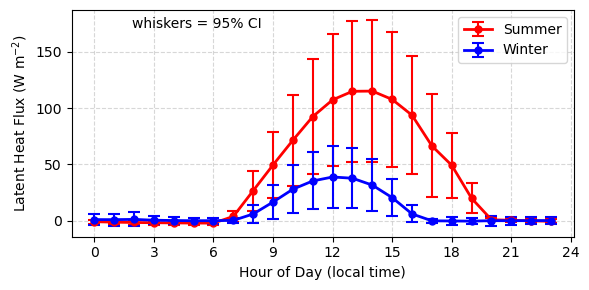

In [7]:
urban_mask_path = '/home1/kojoseph/ah-la-paper/data/urban_mask/wrf_urban_mask-v4.gpkg'

# -----------------------------
# Build urban mask ONCE
# -----------------------------
# Use one dataset just to get grid
sample_exp = simulations["control"]["summer"]
sample_dir = os.path.join(run_dir, sample_exp)
sample_files = sorted(glob.glob(os.path.join(sample_dir, "wrfout_d02*")))

ds_sample = xr.open_mfdataset(
    sample_files,
    engine="netcdf4",
    concat_dim="Time",
    combine="nested"
).xwrf.postprocess()

lats = ds_sample["XLAT"].values
lons = ds_sample["XLONG"].values
ny, nx = lats.shape

# Build point GeoDataFrame
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lons.ravel(), lats.ravel()),
    crs="EPSG:4326"
)

# Load and align mask CRS
urban_mask = gpd.read_file(urban_mask_path).to_crs("EPSG:4326")

# Spatial join (ONLY ONCE)
joined = gpd.sjoin(points, urban_mask, predicate="intersects")

# Build boolean mask
mask_flat = np.zeros(lats.size, dtype=bool)
mask_flat[joined.index] = True
mask_2d = mask_flat.reshape(ny, nx)

# Convert to xarray DataArray
urban_mask_xr = xr.DataArray(mask_2d, dims=("y", "x"))

print("Urban cells:", mask_2d.sum())


# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], 'LH', urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], 'LH', urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,3))

hours = mean_summer["hour"].values

# ---- Plot with caps + thicker lines ----
plt.errorbar(
    hours, mean_summer, yerr=std_summer,
    fmt='o-', color='red', ecolor='red',
    elinewidth=1.5, capsize=4, capthick=1.5,
    markersize=5, linewidth=2,
    label="Summer"
)

plt.errorbar(
    hours, mean_winter, yerr=std_winter,
    fmt='o-', color='blue', ecolor='blue',
    elinewidth=1.5, capsize=4, capthick=1.5,
    markersize=5, linewidth=2,
    label="Winter"
)

# ---- Axes formatting ----
plt.xlabel("Hour of Day (local time)")
plt.ylabel("Latent Heat Flux (W m$^{-2}$)")

# ticks every 3 hours
plt.xticks(np.arange(0, 25, 3))

# match clean paper style
plt.grid(True, linestyle='--', alpha=0.5)

# optional: tighten y limits if needed
# plt.ylim(bottom=0)

plt.legend(frameon=True)

# annotation like Figure 5
plt.text(0.25, 0.92, "whiskers = 95% CI",
         transform=plt.gca().transAxes,
         ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# PBL

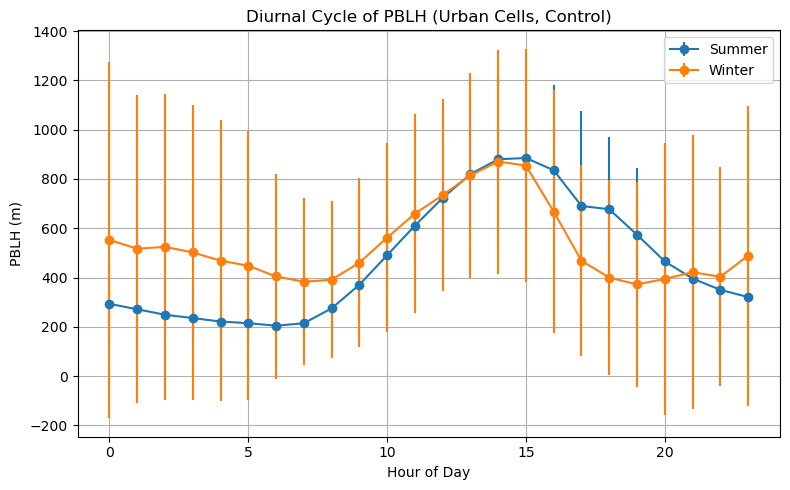

In [20]:
variable = 'PBLH'
variable_units = 'm'
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Wind

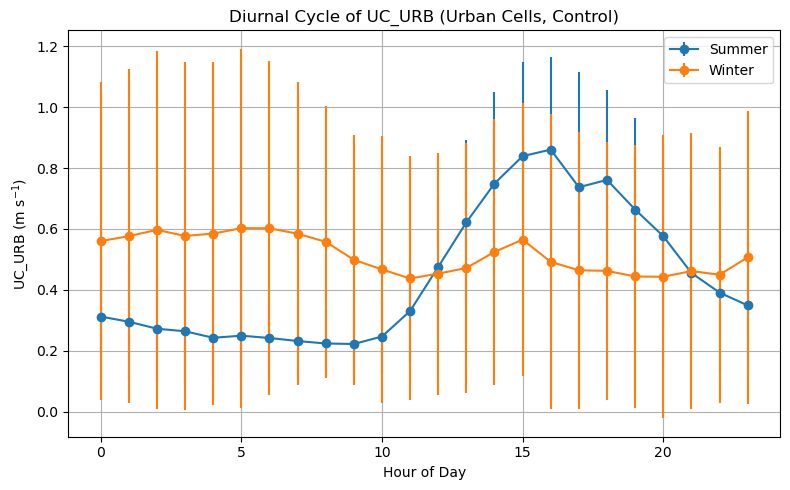

In [21]:
variable = 'UC_URB'
variable_units = r"m s$^{-1}$"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Turbulence / Mixing

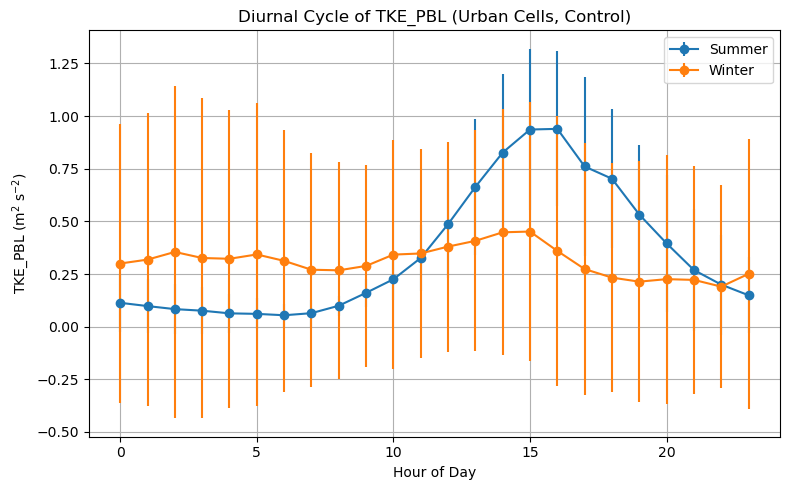

In [24]:
variable = 'TKE_PBL'
variable_units = r"m$^{2}$ s$^{-2}$"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Friction Velocity

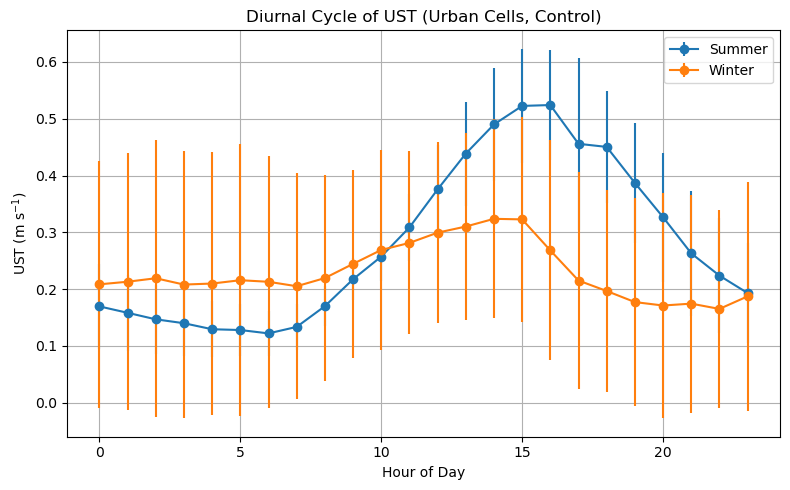

In [25]:
variable = 'UST'
variable_units = r"m s$^{-1}$"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Ts - Ta

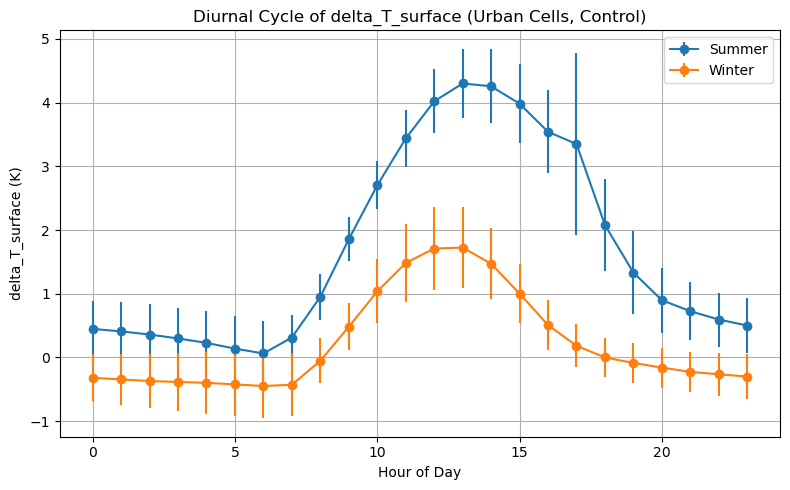

In [27]:
variable = 'delta_T_surface'
variable_units = r"K"
# -----------------------------
# Run simulations
# -----------------------------
mean_summer, std_summer = compute_diurnal_cycle(simulations["control"]["summer"], variable, urban_mask_xr)
mean_winter, std_winter = compute_diurnal_cycle(simulations["control"]["winter"], variable, urban_mask_xr)


# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))

hours = mean_summer["hour"].values

plt.errorbar(hours, mean_summer, yerr=std_summer, marker='o', label="Summer")
plt.errorbar(hours, mean_winter, yerr=std_winter, marker='o', label="Winter")

plt.xlabel("Hour of Day")
plt.ylabel(f"{variable} ({variable_units})")
plt.title(f"Diurnal Cycle of {variable} (Urban Cells, Control)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()